# 0. Setup

In [1]:
from pathlib import Path
from typing import Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import rasterio

from wildfire_susceptibility.config.loader import ConfigLoader
from wildfire_susceptibility.viz.charts import plot_nan_coverage, plot_vif_correlation, plot_class_balance
from wildfire_susceptibility.viz.maps import render_all_factor_maps
from wildfire_susceptibility.viz.manifest import append_to_manifest
from wildfire_susceptibility.features.vegetation import VegetationBuilder

cfg_obj = ConfigLoader.load_experiment(name="baseline")
cfg = cfg_obj.model_dump(mode="python")
figures_dir = cfg_obj.base.figures_dir
dem_path = cfg_obj.base.output_dir / "topo_elevation.tif"

c:\Users\rcorr\anaconda3\envs\wildfire\Lib\site-packages\pyproj\network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


# 1. Helpers 

In [2]:
def season_of_month(m: int) -> str:
    if m in [12, 1, 2]:
        return "WINTER"
    elif m in [3, 4, 5]:
        return "SPRING"
    elif m in [6, 7, 8]:
        return "SUMMER"
    elif m in [9, 10, 11]:
        return "FALL"
    return "?"


def load_climate_timeseries(config, var_name, year_range=None):
    """Full monthly time series (pre seasonal-average) for one HadUK variable,
    spatially averaged across Essex."""
    import xarray as xr
    data_dir = Path(config["data_sources"]["haduk"]["data_dir"]) / var_name
    files = sorted(data_dir.glob("*.nc"))
    ds = xr.open_mfdataset(files, combine="by_coords")
    da = ds[var_name]
    if year_range:
        da = da.sel(time=slice(f"{year_range[0]}-01-01", f"{year_range[1]}-12-31"))
    return da.mean(dim=["projection_x_coordinate", "projection_y_coordinate"]).to_series()


def temporal_eda_report(series, name, figures_dir):
    """STL decomposition + ADF stationarity test + ACF/PACF for one feature's
    time series. Saves figures, returns summary stats."""
    from statsmodels.tsa.seasonal import STL
    from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
    from statsmodels.tsa.stattools import adfuller

    fig, axes = plt.subplots(3, 1, figsize=(10, 9))
    series.plot(ax=axes[0], title=f"{name} — raw monthly series")

    stl = STL(series, period=12, robust=True).fit()
    stl.seasonal.plot(ax=axes[1], title="Seasonal component")
    stl.resid.plot(ax=axes[2], title="Residual (deseasonalized)")
    fig.tight_layout()

    out_dir = Path(figures_dir) / "temporal_eda"
    out_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_dir / f"{name}_decomposition.png", dpi=150)
    plt.close(fig)

    fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    plot_acf(series.dropna(), ax=ax1, lags=36)
    plot_pacf(series.dropna(), ax=ax2, lags=36)
    fig2.savefig(out_dir / f"{name}_acf_pacf.png", dpi=150)
    plt.close(fig2)

    adf_stat, adf_p, *_ = adfuller(series.dropna())
    return {"feature": name, "adf_stat": adf_stat, "adf_p": adf_p,
            "stationary": adf_p < 0.05}


def variance_decomposition(series, season_months):
    """% of total variance explained by season (between) vs within-season
    month-to-month variation. High between-season % justifies collapsing
    to a seasonal mean rather than keeping full monthly observations."""
    labels = series.index.month.map(
        lambda m: next(s for s, months in season_months.items() if m in months)
    )
    df = pd.DataFrame({"value": series.values, "season": labels})
    grand_mean = df["value"].mean()
    between = df.groupby("season")["value"].mean()
    ss_between = (df.groupby("season").size() * (between - grand_mean) ** 2).sum()
    ss_within = df.groupby("season")["value"].apply(lambda x: ((x - x.mean()) ** 2).sum()).sum()
    return {"pct_variance_between_seasons": 100 * ss_between / (ss_between + ss_within)}


def render_nan_map(feature_paths: Dict[str, Path], figures_dir: Path, season=None) -> Path:
    """Composite map: count of NaN features per pixel, across a feature set."""
    arrays = []
    for path in feature_paths.values():
        with rasterio.open(path) as src:
            arrays.append(np.isnan(src.read(1)))
    nan_count = np.sum(arrays, axis=0)

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(np.ma.masked_equal(nan_count, 0), cmap="Reds", vmin=1, vmax=len(feature_paths))
    ax.set_title("NaN feature count per pixel" + (f" — {season}" if season else ""))
    ax.axis("off")
    plt.colorbar(im, ax=ax, label="# features NaN")

    out_path = Path(figures_dir) / (season or "static") / "eda" / "nan_map.png"
    out_path.parent.mkdir(parents=True, exist_ok=True)
    fig.tight_layout()
    fig.savefig(out_path, dpi=150)
    plt.close(fig)
    append_to_manifest(figures_dir, out_path, "nan_coverage_map", "notebook.render_nan_map", season)
    return out_path


def global_morans_i(values_2d: np.ndarray, subsample_stride: int = 1):
    """Global Moran's I on a 2D array (NaN-aware, queen contiguity).
    subsample_stride > 1 downsamples the lattice for speed on full-res rasters."""
    from libpysal.weights import lat2W
    from esda.moran import Moran

    arr = values_2d[::subsample_stride, ::subsample_stride]
    flat = arr.flatten()
    valid_mask = ~np.isnan(flat)

    w = lat2W(*arr.shape, rook=False)
    w_valid_ids = [i for i in range(len(flat)) if valid_mask[i]]
    # esda/libpysal require a fully-connected weight matrix over valid ids;
    # simplest robust route: fill NaNs with the array mean so the lattice
    # stays complete, and note that filled cells contribute no new signal.
    filled = np.where(valid_mask, flat, np.nanmean(flat))
    mi = Moran(filled, w, permutations=999)
    return {"I": mi.I, "p_sim": mi.p_sim, "z_sim": mi.z_sim, "n_valid": int(valid_mask.sum())}

# 2. Fire Incident QA: duplicates & the 2009 anomaly

In [3]:
incidents_df = pd.read_csv("./data/bronze/incidents/OutdoorFIres_2009_2025.csv")
incidents_df["CallDateID"] = pd.to_datetime(incidents_df["CallDateID"], dayfirst=True)
incidents_df["Year"] = incidents_df["CallDateID"].dt.year
incidents_df["Month"] = incidents_df["CallDateID"].dt.month

print("Exact duplicate rows:", incidents_df.duplicated().sum())

same_day_loc = incidents_df.duplicated(
    subset=["CallDateID", "IncidentEasting", "IncidentNorthing"], keep=False
)
print("Same day+location duplicates:", same_day_loc.sum())

Exact duplicate rows: 0
Same day+location duplicates: 734


In [4]:
# Diagnose the 2009 spike BEFORE dropping anything, so we can see what's
# actually driving it (identical-coordinate placeholder geocoding vs.
# genuine incident volume vs. a different logging granularity that year).
d09 = incidents_df[incidents_df["Year"] == 2009]
coord_counts = d09.groupby(["IncidentEasting", "IncidentNorthing"]).size().sort_values(ascending=False)
print("Top repeated coordinates in 2009:")
print(coord_counts.head(20))

# Compare deployment granularity: if 2009 has much lower mean vehicles/incident
# than surrounding years, incidents may have been logged at finer granularity
# that year (e.g. one row per appliance) rather than truly more fires.
print(incidents_df.groupby("Year")["NumberVehiclesDeployed"].mean())

Top repeated coordinates in 2009:
IncidentEasting  IncidentNorthing
568576           182699              9
577558           183840              9
578127           184811              7
583860           192492              7
570593           187284              6
545554           207527              5
561100           179924              5
578679           184789              5
615366           214645              5
545062           208835              4
568956           182912              4
578134           184133              4
578194           183738              4
556302           181371              3
563189           176974              3
564305           176585              3
572606           188445              3
544872           208886              3
565034           176164              3
576000           183900              3
dtype: int64
Year
2009    1.331593
2010    1.317073
2011    1.300370
2012    1.321277
2013    1.295941
2014    1.364696
2015    1.367235
2016    1.45898

Dropped 382 duplicate rows (30,070 -> 29,688)


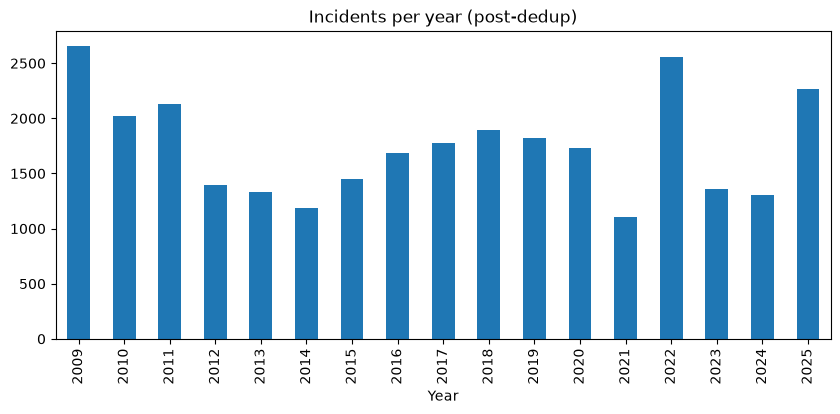

In [5]:
# Drop same-day/same-location duplicates (the clearest re-logging signature)
before_n = len(incidents_df)
incidents_df = incidents_df.drop_duplicates(
    subset=["CallDateID", "IncidentEasting", "IncidentNorthing"]
).reset_index(drop=True)
print(f"Dropped {before_n - len(incidents_df):,} duplicate rows ({before_n:,} -> {len(incidents_df):,})")

yearly_counts = incidents_df["Year"].value_counts().sort_index()
yearly_counts.plot(kind="bar", figsize=(10, 4), title="Incidents per year (post-dedup)")
plt.show()

# 3. Seasonal distribution of fires

Season
SUMMER    45.981541
SPRING    24.481272
FALL      21.924683
WINTER     7.612503
Name: proportion, dtype: float64


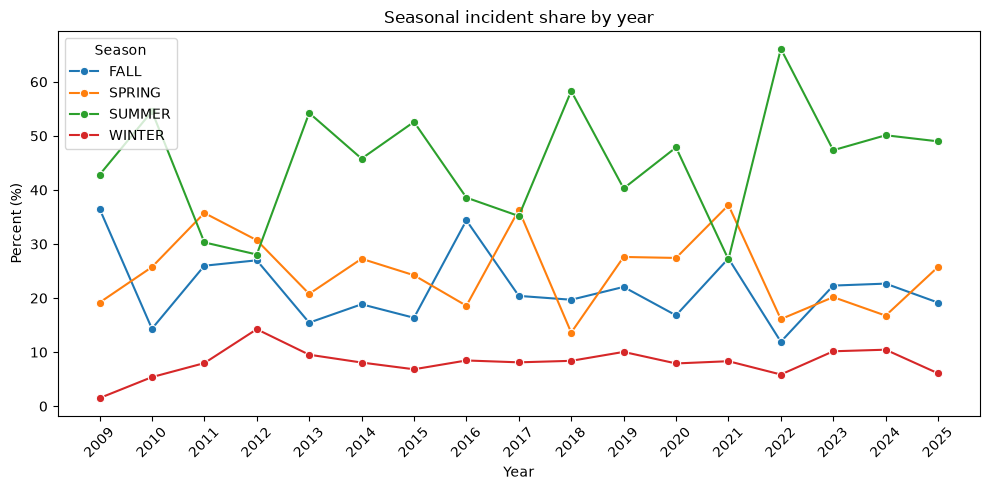

In [6]:
temp = incidents_df[["Year", "Month"]].copy()
temp["Season"] = temp["Month"].apply(season_of_month)

print(temp["Season"].value_counts(normalize=True) * 100)

season_year_counts = temp.groupby(["Season", "Year"]).size().unstack(fill_value=0)
pct_season_year_counts = 100 * season_year_counts / season_year_counts.sum(axis=0)

df_long = pct_season_year_counts.reset_index().melt(
    id_vars="Season", var_name="Year", value_name="Percent (%)"
)
df_long["Year"] = df_long["Year"].astype(int)

plt.figure(figsize=(10, 5))
sns.lineplot(data=df_long, x="Year", y="Percent (%)", hue="Season", marker="o")
plt.title("Seasonal incident share by year")
plt.xticks(sorted(df_long["Year"].unique()), rotation=45)
plt.tight_layout()
plt.show()

# 4. Temporal EDA per feature (univariate + variance decomposition)

INFO: Logger initialized: wildfire_susceptibility


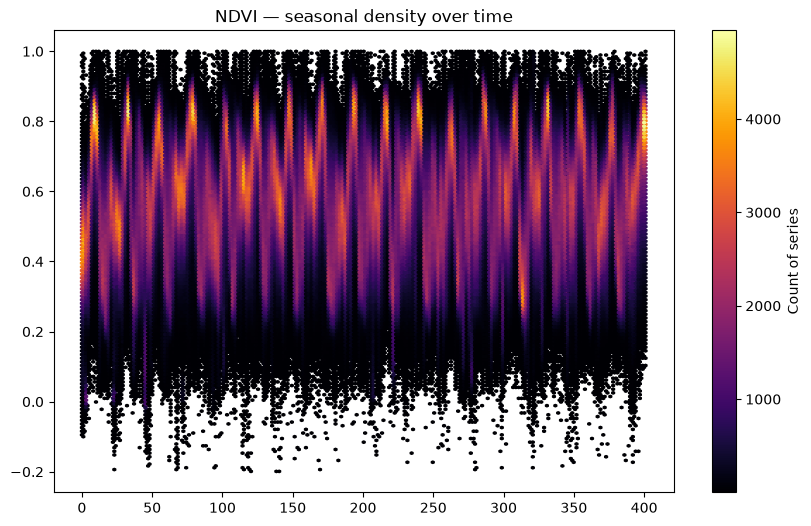

In [7]:
season_months = cfg["seasons"]["definitions"]  # {"spring": [...], ...}

# --- NDVI ---
veg_builder = VegetationBuilder(cfg)
ndvi_arr = veg_builder.eda_debug()   # (n_days, H, W)

ndvi_flat_df = pd.DataFrame(ndvi_arr.reshape((ndvi_arr.shape[0], -1))).dropna(how="any", axis=1)
ndvi_long = (
    ndvi_flat_df.reset_index(drop=False, names="day")
    .melt(id_vars="day", var_name="pixel", value_name="ndvi")
)

plt.figure(figsize=(10, 6))
plt.hexbin(ndvi_long["day"], ndvi_long["ndvi"], gridsize=200, cmap="inferno", mincnt=1)
plt.colorbar(label="Count of series")
plt.title("NDVI — seasonal density over time")
plt.show()

In [8]:
# --- Climate variables: full temporal EDA battery ---
climate_vars = cfg["data_sources"]["haduk"]["sources"]  # tas, tasmax, tasmin, rainfall, sfcWind, hurs
temporal_summary = []

for var in climate_vars:
    series = load_climate_timeseries(cfg, var, year_range=cfg["processing"]["training_years"])
    stats = temporal_eda_report(series, var, figures_dir)
    var_decomp = variance_decomposition(series, season_months)
    temporal_summary.append({**stats, **var_decomp})

temporal_summary_df = pd.DataFrame(temporal_summary)
temporal_summary_df

C:\Users\rcorr\AppData\Local\Temp\ipykernel_15160\2627896729.py:19: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mfdataset(files, combine="by_coords")
C:\Users\rcorr\AppData\Local\Temp\ipykernel_15160\2627896729.py:19: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mfdataset(files, com

,feature,adf_stat,adf_p,stationary,pct_variance_between_seasons
0,tas,-2.421129,1.358615e-01,False,77.719852
1,tasmax,-2.910624,4.412639e-02,True,76.923546
2,tasmin,-2.813796,5.632995e-02,False,76.685112
3,rainfall,-3.080566,2.802522e-02,True,23.197818
4,sfcWind,-7.850267,5.625622e-12,True,30.191414
5,hurs,-3.389888,1.130846e-02,True,63.863452


# 5. Nan Analysis

In [9]:
for season in cfg_obj.seasons.active:
    df = pd.read_csv(cfg_obj.base.model_data_dir / f"dataset_train_{season}.csv")
    feature_cols = [c for c in df.columns if c != "label"]
    feature_arrays = {c: df[c].values for c in feature_cols}
    plot_nan_coverage(feature_arrays, figures_dir, season=season)

    nan_summary = df[feature_cols].isna().sum().sort_values(ascending=False)
    n_rows_any_nan = df[feature_cols].isna().any(axis=1).sum()
    print(f"[{season}] rows with >=1 NaN feature: {n_rows_any_nan:,} / {len(df):,}")
    print(nan_summary[nan_summary > 0])

[summer] rows with >=1 NaN feature: 39,746 / 3,851,135
tas              38868
hurs             38868
tasmax           38868
rainfall         38868
diurnal_range    38868
tasmin           38868
sfcWind          38868
ndvi              1733
dtype: int64


In [10]:
# Spatial NaN map — confirms the three documented NaN sources are spatially
# distinct (coastal/estuary mask, flat-terrain SRTM no-data, scattered cloud
# contamination), rather than overlapping in a way that would compound loss.
for season in cfg_obj.seasons.active:
    feature_paths = {
        "tasmax": cfg_obj.base.output_dir / f"meteo_tasmax_{season}_train.tif",
        "slope":  cfg_obj.base.output_dir / "topo_slope.tif",
        "ndvi":   cfg_obj.base.output_dir / f"ndvi_{season}_train.tif",
    }
    feature_paths = {k: v for k, v in feature_paths.items() if v.exists()}
    if feature_paths:
        render_nan_map(feature_paths, figures_dir, season=season)

# 6. VIF / Correlation / Class balance

In [12]:
for season in cfg_obj.seasons.active:
    df = pd.read_csv(cfg_obj.base.model_data_dir / f"dataset_train_{season}.csv")
    feature_cols = [c for c in df.columns if c not in ["label", "_x", "_y", "tas", "tasmin"]]
    plot_vif_correlation(
        df, feature_cols, figures_dir, season=season, vif_threshold=10.0, corr_threshold=0.8,
    )

# Class balance before/after label cleaning (uncomment once risk_labels_clean_*.tif exist)
# for season in cfg_obj.seasons.active:
#     with rasterio.open(cfg_obj.base.output_dir / f"risk_labels_{cfg_obj.labels.density_method}_{cfg_obj.labels.classify_method}_{season}_train.tif") as src:
#         before = src.read(1)
#     with rasterio.open(cfg_obj.base.output_dir / f"risk_labels_clean_{season}_train.tif") as src:
#         after = src.read(1)
#     plot_class_balance(before, after, figures_dir, season=season)

In [13]:
# Coefficient of variation per feature, per season — quick scan for
# near-constant features that would add little discriminative signal.
cov_by_season = {}
for season in cfg_obj.seasons.active:
    df = pd.read_csv(cfg_obj.base.model_data_dir / f"dataset_train_{season}.csv")
    feature_cols = [c for c in df.columns if c != "label"]
    cov_by_season[season] = df[feature_cols].std() / df[feature_cols].mean()

pd.concat(cov_by_season, axis=1).T

,elevation,slope,aspect,d_roads,d_rivers,d_buildings,landuse_class,tas,tasmax,tasmin,rainfall,sfcWind,hurs,diurnal_range,ndvi,_x,_y
summer,0.616912,0.708777,0.573273,1.036536,0.749506,0.826792,0.73572,0.018558,0.013115,0.044203,0.087203,0.066082,0.008626,0.059425,0.140335,0.035338,0.071461


# 7. Factor maps

In [14]:
static_paths = {
    "elevation": cfg_obj.base.output_dir / "topo_elevation.tif",
    "slope": cfg_obj.base.output_dir / "topo_slope.tif",
    "aspect": cfg_obj.base.output_dir / "topo_aspect.tif",
    "d_rivers": cfg_obj.base.output_dir / "dist_rivers.tif",
    "d_roads": cfg_obj.base.output_dir / "dist_roads.tif",
    "d_buildings": cfg_obj.base.output_dir / "dist_buildings.tif",
    "land_use": cfg_obj.base.output_dir / "landuse_class.tif",
}
render_all_factor_maps(static_paths, dem_path, figures_dir)

for season in cfg_obj.seasons.active:
    seasonal_paths = {
        "tas": cfg_obj.base.output_dir / f"meteo_tas_{season}_train.tif",
        "tasmax": cfg_obj.base.output_dir / f"meteo_tasmax_{season}_train.tif",
        "tasmin": cfg_obj.base.output_dir / f"meteo_tasmin_{season}_train.tif",
        "hurs": cfg_obj.base.output_dir / f"meteo_hurs_{season}_train.tif",
        "sfcWind": cfg_obj.base.output_dir / f"meteo_sfcWind_{season}_train.tif",
        "rainfall": cfg_obj.base.output_dir / f"meteo_rainfall_{season}_train.tif",
        "d_fires": cfg_obj.base.output_dir / f"dist_fires_{season}.tif",
        "ndvi": cfg_obj.base.output_dir / f"ndvi_{season}_train.tif",
    }
    seasonal_paths = {k: v for k, v in seasonal_paths.items() if v.exists()}
    render_all_factor_maps(seasonal_paths, dem_path, figures_dir, season=season)

# 8. Spatial EDA

In [15]:
# Global Moran's I on fire density — direct evidence for spatial
# autocorrelation motivating the stratified spatial block CV contribution.
for season in cfg_obj.seasons.active:
    density_path = cfg_obj.base.output_dir / f"fire_density_conv_{season}_train.tif"
    if not density_path.exists():
        continue
    with rasterio.open(density_path) as src:
        density = src.read(1)
    result = global_morans_i(density, subsample_stride=4)  # stride for speed on full-res grid
    print(f"[{season}] Moran's I = {result['I']:.4f} (p={result['p_sim']:.4f}, n={result['n_valid']:,})")

c:\Users\rcorr\anaconda3\envs\wildfire\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[summer] Moran's I = 0.6926 (p=0.0010, n=240,682)


In [16]:
# Correlogram: Moran's I as a function of distance lag — empirically
# justifies spatial_block_size_m (should exceed the autocorrelation range).
def correlogram(values_2d, cell_size_m, max_lag_cells=20, stride=4):
    from libpysal.weights import lat2W
    from esda.moran import Moran

    arr = values_2d[::stride, ::stride]
    filled = np.where(np.isnan(arr), np.nanmean(arr), arr).flatten()
    results = []
    for lag in range(1, max_lag_cells + 1):
        w = lat2W(*arr.shape, rook=False)  # simple proxy; a true distance-band
        # weight would use libpysal.weights.DistanceBand for exact lag control
        mi = Moran(filled, w, permutations=99)
        results.append({"lag_cells": lag, "lag_m": lag * cell_size_m * stride, "I": mi.I})
    return pd.DataFrame(results)

# Run only if the above global Moran's I confirms significant autocorrelation